In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from AI4AO import PyramidWFS
from AI4AO import DeformableMirror

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time


In [2]:
papyrus_iMat = np.load("../Data/Papyrus/Papyrus_iMat.npy")
papyrus_iMat = torch.from_numpy(papyrus_iMat.astype(np.float32)).to(device = device, dtype=torch.float32)

M2C = np.load("../Data/Papyrus/M2C.npy")
M2C = torch.from_numpy(M2C).to(device = device, dtype = torch.float32)

reference_frame = np.load('../Data/Papyrus/Reference_frame.npy')
reference_frame = torch.from_numpy(reference_frame).to(device = device, dtype = torch.float32)
reference_frame = reference_frame.view(240,240)
reference_frame /= reference_frame.sum()

In [3]:
WFSParams = {"Nres":76,
             "sampling":240/76,
             "D": 1.52,
             "useNoise": False,
             "Modulation": 3,
             "MaskType": "Pyramid",
             "beamSplitProportionForWFSDetector": 0,
             "Nactuator": 17,
             "Wavelength": 635e-9
             }


wfs = PyramidWFS(WFSParams, device)

c:\Users\foyarzun\AOvenv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


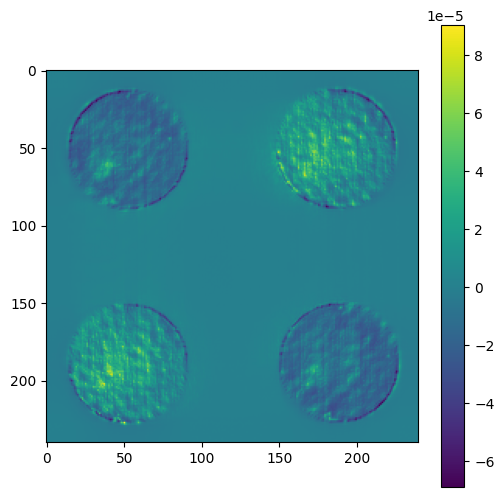

In [5]:
final_train_loss = 0

TrainRunNb = 200
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW(wfs.parameters(), 1e-3, fused = True)

wfs.train()

for u in range(0,TrainRunNb) :

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity
    
    l = (torch.abs(reference_frame-digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - wfs.reference_intensity).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



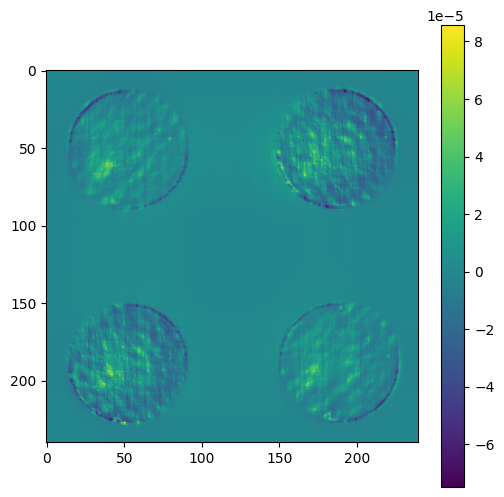

In [6]:
final_train_loss = 0

TrainRunNb = 100
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW([wfs.rooftop], 1e-1, fused = True)
wfs.train()

bench_quadrants = reference_frame.view(2,120,2,120).permute(0,2,1,3)
bench_quadrants = bench_quadrants.sum(dim = (-2,-1))



for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity
    digital_quadrants = digital_image.view(2,120,2,120).permute(0,2,1,3)
    digital_quadrants = digital_quadrants.sum(dim = (-2,-1))
    
    l = loss(bench_quadrants,digital_quadrants)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - digital_image).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



In [7]:
DMParams = {"moffatParam": 2,
            "signedAmplitude": -5e-6,
            "MechCoupling": 0.36,
            "FlipLeftRight": True,
            "FlipTopBottom": False}

param = {}
param['rotationAngle'] = 0
# shift X in m
param['shiftX'] = 0
# shift Y in m
param['shiftY'] = 0
# amamorphosis angle in degrees
param['anamorphosisAngle'] = 0
# normal scaling in % of diameter
param['tangentialScaling'] = 0
# radial scaling in % of diameter
param['radialScaling'] = 0

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device,
                    misreg=param)


wfs.BuildReferenceIntensity()
dm.RoughCalibration(wfs, papyrus_iMat, M2C)


Best configuration found to be: 
Rotation angle: 90.0
Sign: Negative
Flip left-right: True
Flip top-bottom: False

Updating values in the DM


In [8]:
ref_phase = torch.nn.Parameter(torch.zeros(*wfs.pupil.shape, device = device, dtype = torch.float32))
ref_pupil = torch.nn.Parameter(torch.ones(*wfs.pupil.shape, device = device, dtype = torch.float32))

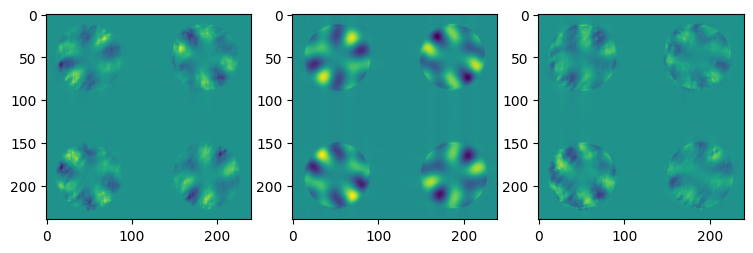

In [9]:
index = list(range(0,190,5))
target = papyrus_iMat[index]

dm.modesComputation()
modes = dm.GetModalModes(M2C[:,index])

wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)
digital_image = wfs.iMat

idx = 3
plt.figure(figsize=(9,4))
plt.subplot(131)
plt.imshow(target[idx].cpu().numpy())

plt.subplot(132)
plt.imshow(digital_image[idx].cpu().detach().numpy())

plt.subplot(133)
plt.imshow((target - digital_image)[idx].cpu().detach().numpy(), vmin=(target)[idx].cpu().detach().numpy().min(), vmax=(target)[idx].cpu().detach().numpy().max())

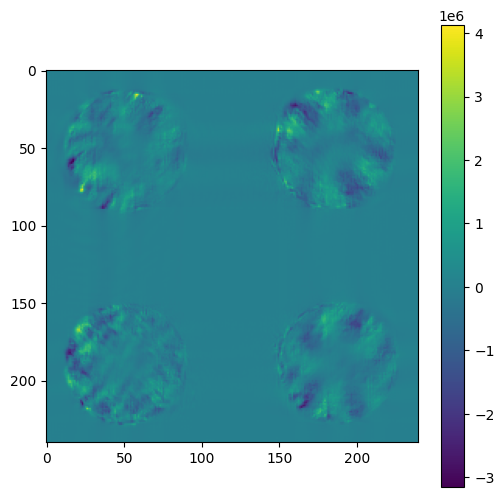

########################################
loss = 0.00962
########################################
({'rotationAngle': 90.33180236816406, 'shiftX': -0.05823513031005859, 'shiftY': 0.02205737590789795, 'anamorphosisAngle': -88.02310943603516, 'tangentialScaling': 9.090165793895721, 'radialScaling': 8.549635857343674}, {'moffatParam': 1.986699104309082, 'signedAmplitude': -4.234216703480342e-06, 'MechCoupling': 0.2665572762489319, 'FlipLeftRight': True, 'FlipTopBottom': False})


In [11]:
TrainRunNb = 200

loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))

img = ax.imshow(target[4].cpu().detach().numpy())
fig.colorbar(img)

original_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
original_positons = dm.rotate_coordinates(original_positons)


warmup_iters = TrainRunNb // 2
lr_start = -10
lr_end = -2

optimizer = torch.optim.AdamW(  [{"params": dm.parameters(), "lr": 1e-2},
                                {"params": [ref_phase, ref_pupil], "lr": 10**lr_start}],
                                fused=True
                                )


wfs.reference_intensity = None

for u in range(0,TrainRunNb) :

    if u < warmup_iters:
        alpha = u / warmup_iters
        optimizer.param_groups[1]["lr"] = 10**(
            lr_start + alpha * (lr_end - lr_start)
        )
    if u == warmup_iters:
        optimizer.param_groups[1]["lr"] = 10**lr_end
    
    optimizer.zero_grad()
    wfs.BuildMask()
    
    dm.modesComputation()
    modes = dm.GetModalModes(M2C[:,index])

    wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

    digital_image = wfs.iMat
    
    l = ((target - digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((target - digital_image)[4].cpu().detach().numpy()*1e10)
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.5)

        print("#"*40)
        print(f'loss = {l.item():.5f}')
        print("#"*40)
    
print(dm.GetMisreg())

transformed_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
transformed_positons = dm.rotate_coordinates(transformed_positons)

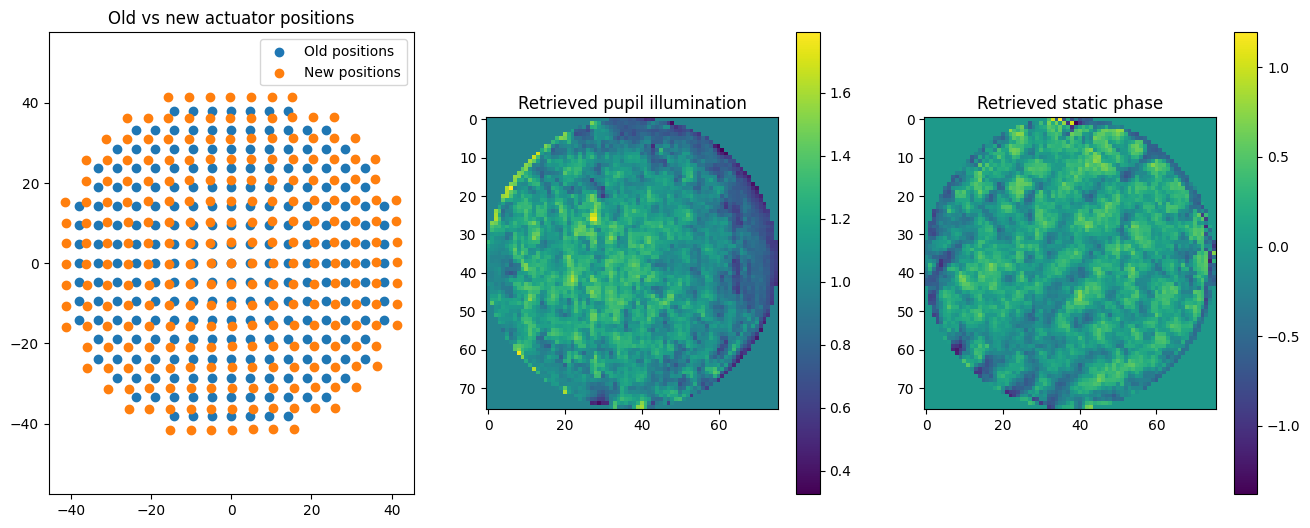

In [12]:
plt.figure(figsize=(16,6))
plt.subplot(131)
plt.title("Old vs new actuator positions")
plt.scatter(original_positons[:,0].cpu().detach(), original_positons[:,1].cpu().detach())
plt.scatter(transformed_positons[:,0].cpu().detach(), transformed_positons[:,1].cpu().detach())
plt.legend(['Old positions', 'New positions'])
plt.axis('equal')
plt.subplot(132)
plt.title('Retrieved pupil illumination')
plt.imshow(ref_pupil.cpu().detach())
plt.colorbar()
plt.subplot(133)
plt.title('Retrieved static phase')
plt.imshow(ref_phase.cpu().detach())
plt.colorbar()

In [13]:
dm.modesComputation()
modes = dm.GetModalModes(M2C)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

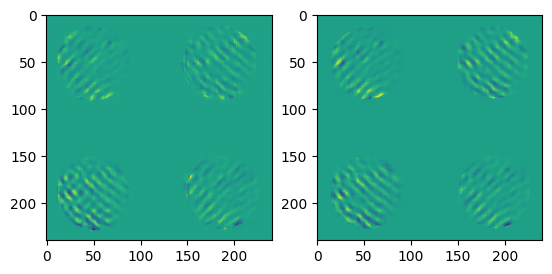

In [19]:
idx = 176
plt.subplot(121)
plt.imshow((papyrus_iMat)[idx].cpu().detach().numpy())
plt.subplot(122)
plt.imshow((wfs.iMat)[idx].cpu().detach().numpy())

In [15]:
with torch.no_grad():
    cov = papyrus_iMat.view(195,-1) @ wfs.reconstructionMatrix

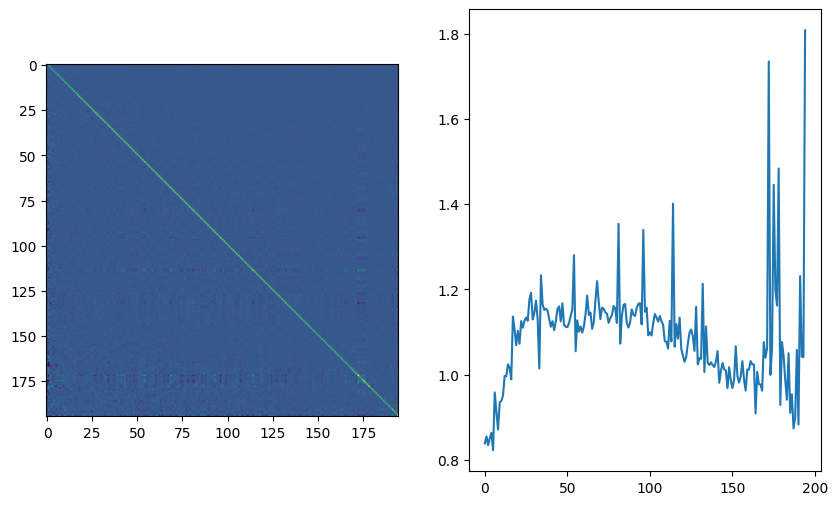

In [16]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

In [31]:
misreg, dmdict = dm.GetMisreg()

print(misreg)

print(dmdict)

{'rotationAngle': 90.50592041015625, 'shiftX': -0.05861885070800782, 'shiftY': 0.02315385103225708, 'anamorphosisAngle': 61.8231315612793, 'tangentialScaling': 8.574240654706955, 'radialScaling': 8.335571736097336}
{'moffatParam': 2.7209837436676025, 'signedAmplitude': -4.063724645675393e-06, 'MechCoupling': 0.28966450691223145, 'FlipLeftRight': True, 'FlipTopBottom': False}


In [21]:
PATH_WFS = "../Data/Papyrus/PapyrusWFS.pth"
torch.save(wfs.state_dict(), PATH_WFS)

PATH_DM = "../Data/Papyrus/PapyrusDM.pth"
torch.save(dm.state_dict(), PATH_DM)

checkpoint = torch.load(PATH_WFS, weights_only=True)
wfs.load_state_dict(checkpoint)

checkpoint = torch.load(PATH_DM, weights_only=True)
dm.load_state_dict(checkpoint)

<All keys matched successfully>

In [22]:
dm.GetMisreg()

({'rotationAngle': 90.33180236816406,
  'shiftX': -0.05823513031005859,
  'shiftY': 0.02205737590789795,
  'anamorphosisAngle': -88.02310943603516,
  'tangentialScaling': 9.090165793895721,
  'radialScaling': 8.549635857343674},
 {'moffatParam': 1.986699104309082,
  'signedAmplitude': -4.234216703480342e-06,
  'MechCoupling': 0.2665572762489319,
  'FlipLeftRight': True,
  'FlipTopBottom': False})